In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv(r"C:\Users\bhaya\OneDrive\Desktop\SWYNEX-Data-Cleaning-Preparation(AutoRecovered).1.csv")

In [10]:
df.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [11]:
df.shape

(2000, 17)

In [12]:
df.columns

Index(['id', 'first_name', 'last_name', 'email', 'gender', 'part_time_job',
       'absence_days', 'extracurricular_activities', 'weekly_self_study_hours',
       'career_aspiration', 'math_score', 'history_score', 'physics_score',
       'chemistry_score', 'biology_score', 'english_score', 'geography_score'],
      dtype='object')

In [13]:
df.isnull().sum()

id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
subjects = [
    "math_score",
    "history_score",
    "physics_score",
    "chemistry_score",
    "biology_score",
    "english_score",
    "geography_score"
]

In [16]:
df[subjects].mean()

math_score         83.4520
history_score      80.3320
physics_score      81.3365
chemistry_score    79.9950
biology_score      79.5815
english_score      81.2775
geography_score    80.8880
dtype: float64

In [17]:
df[subjects].min()

math_score         40
history_score      50
physics_score      50
chemistry_score    50
biology_score      30
english_score      50
geography_score    60
dtype: int64

In [18]:
df[subjects].max()

math_score         100
history_score      100
physics_score      100
chemistry_score    100
biology_score      100
english_score       99
geography_score    100
dtype: int64

In [19]:
eda_summary = pd.DataFrame({
    "Subject": subjects,
    "Average": df[subjects].mean().round(2).values,
    "Minimum": df[subjects].min().values,
    "Maximum": df[subjects].max().values
})

eda_summary

,Subject,Average,Minimum,Maximum
0,math_score,83.45,40,100
1,history_score,80.33,50,100
2,physics_score,81.34,50,100
3,chemistry_score,80.00,50,100
4,biology_score,79.58,30,100
5,english_score,81.28,50,99
6,geography_score,80.89,60,100


In [20]:
eda_summary["Subject"] = eda_summary["Subject"].str.replace("_score", "", regex=False).str.title()

eda_summary

,Subject,Average,Minimum,Maximum
0,Math,83.45,40,100
1,History,80.33,50,100
2,Physics,81.34,50,100
3,Chemistry,80.00,50,100
4,Biology,79.58,30,100
5,English,81.28,50,99
6,Geography,80.89,60,100


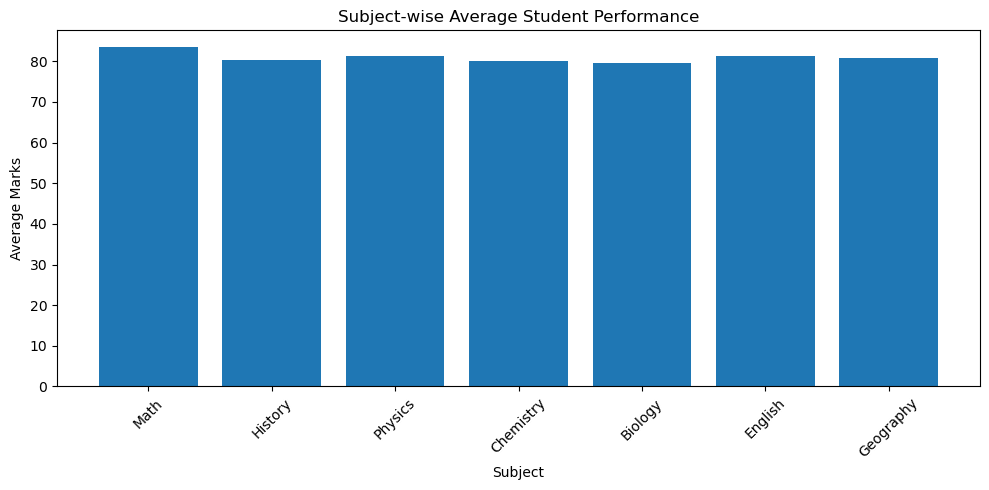

In [21]:
plt.figure(figsize=(10, 5))

plt.bar(eda_summary["Subject"], eda_summary["Average"])

plt.xlabel("Subject")
plt.ylabel("Average Marks")
plt.title("Subject-wise Average Student Performance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

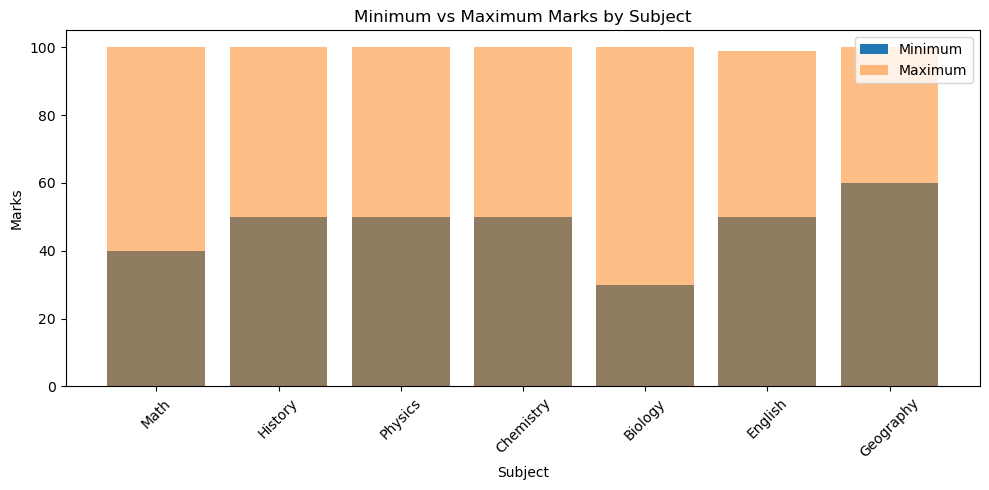

In [22]:
plt.figure(figsize=(10, 5))

plt.bar(eda_summary["Subject"], eda_summary["Minimum"], label="Minimum")
plt.bar(eda_summary["Subject"], eda_summary["Maximum"], alpha=0.5, label="Maximum")

plt.xlabel("Subject")
plt.ylabel("Marks")
plt.title("Minimum vs Maximum Marks by Subject")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
df["overall_average"] = df[subjects].mean(axis=1)

df["overall_average"].head()

0    82.000000
1    91.428571
2    86.428571
3    78.714286
4    74.428571
Name: overall_average, dtype: float64

In [24]:
df["overall_average"].mean(), df["overall_average"].min(), df["overall_average"].max()

(np.float64(80.98035714285714), 59.142857142857146, 96.14285714285714)

In [27]:
def performance_category(score):
    if score >= 90:
        return "Excellent"
    elif score >= 80:
        return "Good"
    elif score >= 70:
        return "Average"
    else:
        return "Needs Improvement"

df["performance_category"] = df["overall_average"].apply(performance_category)

df[["overall_average", "performance_category"]].head(10)

,overall_average,performance_category
0,82.000000,Good
1,91.428571,Excellent
2,86.428571,Good
3,78.714286,Average
4,74.428571,Average
5,82.000000,Good
6,84.714286,Good
7,82.000000,Good
8,81.142857,Good
9,76.714286,Average


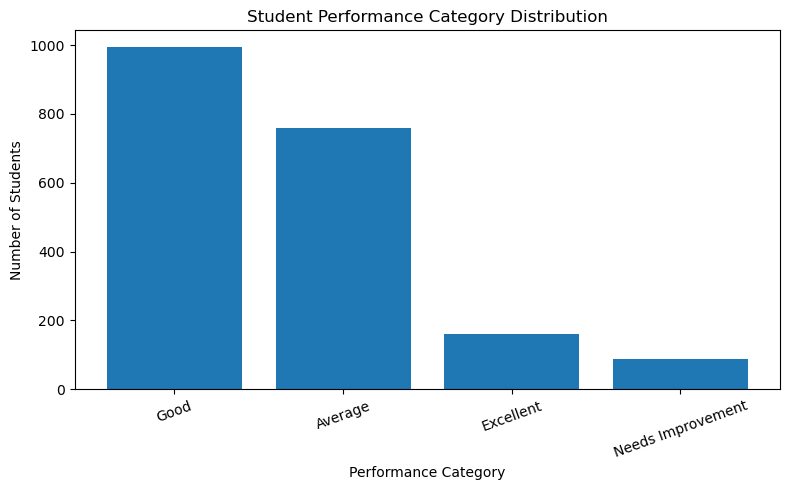

In [28]:
plt.figure(figsize=(8, 5))

plt.bar(performance_counts.index, performance_counts.values)

plt.xlabel("Performance Category")
plt.ylabel("Number of Students")
plt.title("Student Performance Category Distribution")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

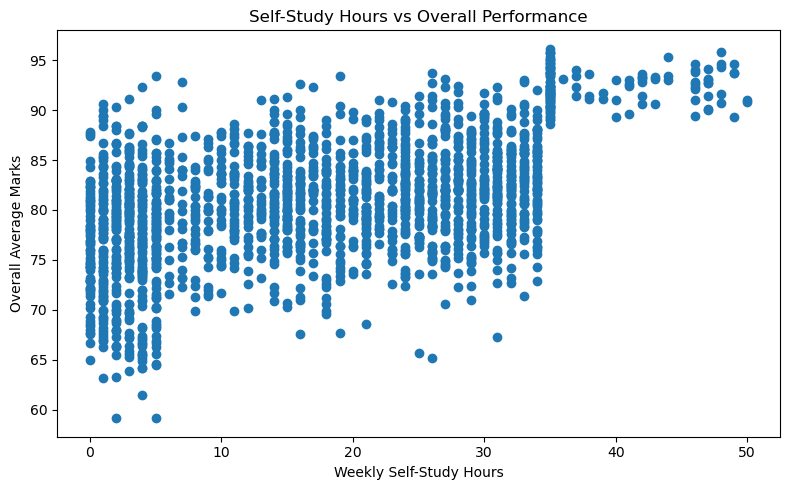

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(df["weekly_self_study_hours"], df["overall_average"])

plt.xlabel("Weekly Self-Study Hours")
plt.ylabel("Overall Average Marks")
plt.title("Self-Study Hours vs Overall Performance")

plt.tight_layout()
plt.show()

In [30]:
study_summary = df.groupby("performance_category")["weekly_self_study_hours"].mean().round(2)

study_summary

performance_category
Average              13.88
Excellent            33.86
Good                 19.26
Needs Improvement     4.56
Name: weekly_self_study_hours, dtype: float64

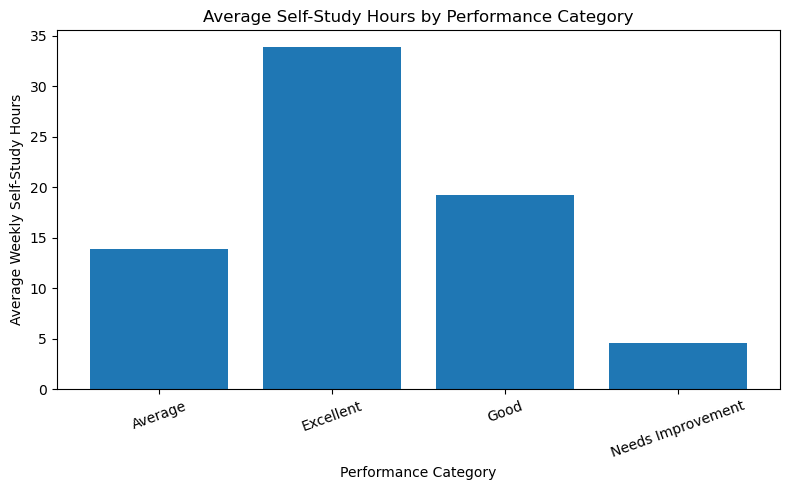

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(study_summary.index, study_summary.values)

plt.xlabel("Performance Category")
plt.ylabel("Average Weekly Self-Study Hours")
plt.title("Average Self-Study Hours by Performance Category")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [32]:
gender_summary = df.groupby("gender")["overall_average"].mean().round(2)


gender_summary

gender
female    80.89
male      81.07
Name: overall_average, dtype: float64

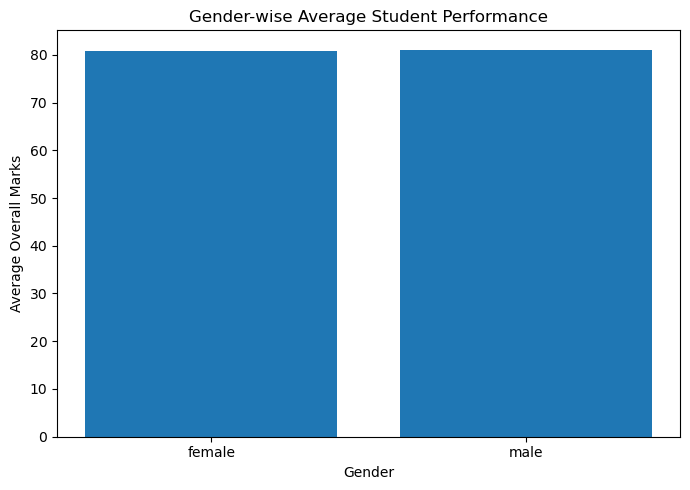

In [33]:
plt.figure(figsize=(7, 5))

plt.bar(gender_summary.index, gender_summary.values)

plt.xlabel("Gender")
plt.ylabel("Average Overall Marks")
plt.title("Gender-wise Average Student Performance")

plt.tight_layout()
plt.show()

In [34]:
final_insights = pd.DataFrame({
    "Metric": [
        "Overall Average Score",
        "Minimum Overall Average",
        "Maximum Overall Average",
        "Top Subject by Average",
        "Lowest Subject by Average",
        "Most Common Performance Category"
    ],
    "Value": [
        round(df["overall_average"].mean(), 2),
        round(df["overall_average"].min(), 2),
        round(df["overall_average"].max(), 2),
        eda_summary.loc[eda_summary["Average"].idxmax(), "Subject"],
        eda_summary.loc[eda_summary["Average"].idxmin(), "Subject"],
        performance_counts.idxmax()
    ]
})

final_insights

,Metric,Value
0,Overall Average Score,80.98
1,Minimum Overall Average,59.14
2,Maximum Overall Average,96.14
3,Top Subject by Average,Math
4,Lowest Subject by Average,Biology
5,Most Common Performance Category,Good
